# =========================================
# E-COMMERCE RECOMMENDATION SYSTEM
# Using Content-Based Filtering
# =========================================

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split




In [ ]:
# LOAD DATASET


df = pd.read_csv(
    "/content/AmazonReviewDataset.csv",
    engine='python',
    on_bad_lines='skip'
)

print("Dataset Shape:", df.shape)

# Select Required Columns

df = df[['ProductId', 'Summary', 'Text', 'Score']]

# Rename columns
df.columns = [
    'product_id',
    'product_name',
    'review',
    'rating'
]

# Remove missing values
df.dropna(inplace=True)

# Remove duplicate products
df.drop_duplicates(
    subset=['product_name'],
    inplace=True
)

# Reduce dataset size for faster execution
df = df.sample(10000, random_state=42)
# Reset index after sampling to ensure continuity with cosine_sim
df.reset_index(drop=True, inplace=True)

print(df.head())

Dataset Shape: (568454, 10)
   product_id                                       product_name  \
0  B000P7345G                                        tomato food   
1  B0000ZSH9Q                     Cranberry Juice, organic, pure   
2  B00764BRS2              MUCH better than Keurig's My K-Cup!!!   
3  B000EVNWSW                                     Not Organic :(   
4  B003Z6ZIZI  Expect Chocolate and You'll likely be Disappoi...   

                                              review  rating  
0  Miracle grow is the best.  I hope I get some b...       5  
1  Best juice I have tasted, and so pure, just  w...       5  
2  My family had been using Keurig's (refillable)...       4  
3  I really like this cereal. I have it almost ev...       3  
4  I recently tried "Brewing Chocolate", which is...       3  


In [ ]:
# TF-IDF VECTORIZATION

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df['review'])

print("\nTF-IDF Matrix Shape:")
print(tfidf_matrix.shape)



TF-IDF Matrix Shape:
(10000, 5000)


In [ ]:
# COSINE SIMILARITY

cosine_sim = cosine_similarity(tfidf_matrix)

print("\nCosine Similarity Shape:")
print(cosine_sim.shape)


Cosine Similarity Shape:
(10000, 10000)


In [ ]:
# CONTENT-BASED RECOMMENDATION FUNCTION


def recommend_products(product_name, top_n=5):

    # Find product index
    indices = pd.Series(
        df.index,
        index=df['product_name']
    ).drop_duplicates()

    if product_name not in indices:
        return "Product not found"

    idx = indices[product_name]

    # Similarity scores
    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    # Sort similarity scores
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Top similar products
    similarity_scores = similarity_scores[1:top_n+1]

    recommended_products = []

    for i in similarity_scores:

        recommended_products.append(
            df.iloc[i[0]]['product_name']
        )

    return recommended_products

In [ ]:
# TEST RECOMMENDATION

sample_product = df['product_name'].iloc[10]

print("\n===================================")
print("SELECTED PRODUCT")
print("===================================")

print(sample_product)

print("\n===================================")
print("RECOMMENDED PRODUCTS")
print("===================================")

recommendations = recommend_products(sample_product)

for i, product in enumerate(recommendations, start=1):

    print(f"{i}. {product}")


SELECTED PRODUCT
Nutrition Informatoin Needs to be Updated

RECOMMENDED PRODUCTS
1. Chocolate with a Fantastic Taste
2. Great shelf-stable milk
3. Great for kids with dairy/soy sensitivities
4. Concerned Grandma
5. Contains a milk derivative


In [ ]:
# TRAIN TEST SPLIT

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

In [ ]:
# PRECISION & RECALL EVALUATION

def evaluate_recommendation_system(top_n=5):

    precisions = []
    recalls = []

    sample_products = test_df['product_name'].head(50)

    for product in sample_products:

        try:

            recommendations = recommend_products(
                product,
                top_n=top_n
            )

            if recommendations == "Product not found":
                continue

            # Relevant products
            relevant_products = set(
                test_df[
                    test_df['rating'] >= 4
                ]['product_name']
            )

            recommended_products = set(recommendations)

            true_positive = len(
                relevant_products.intersection(
                    recommended_products
                )
            )

            precision = (
                true_positive / len(recommended_products)
                if len(recommended_products) > 0 else 0
            )

            recall = (
                true_positive / len(relevant_products)
                if len(relevant_products) > 0 else 0
            )

            precisions.append(precision)
            recalls.append(recall)

        except:
            pass

    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)

    return avg_precision, avg_recall

# MODEL EVALUATION

precision, recall = evaluate_recommendation_system()

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")


MODEL PERFORMANCE
Precision: 0.1600
Recall   : 0.0005


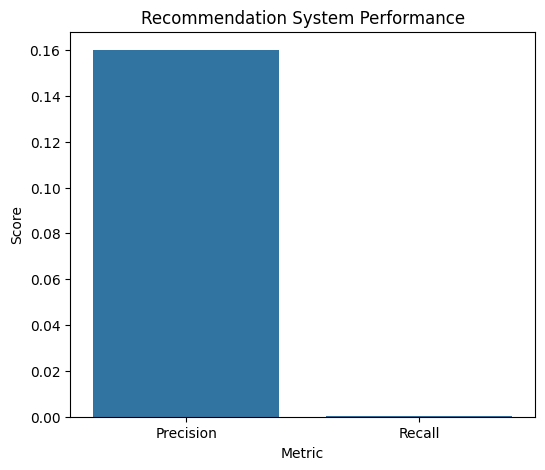

In [ ]:
# VISUALIZATION

metrics = pd.DataFrame({
    'Metric': ['Precision', 'Recall'],
    'Score': [precision, recall]
})

plt.figure(figsize=(6,5))

sns.barplot(
    x='Metric',
    y='Score',
    data=metrics
)

plt.title("Recommendation System Performance")

plt.show()